
# Heart Disease ML Pipeline
# Author: Naveen Patel
# Started: May 2026

## Problem Statement
Heart disease is one of the leading causes of death globally.
Early detection is critical for timely treatment. This project
builds an ML pipeline to predict heart disease risk from patient
medical records — potentially helping doctors screen patients faster.

In [73]:
# Suppress all warnings for clean output
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('shap').setLevel(logging.ERROR)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Step 1: Import all libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)

All libraries loaded successfully!
Pandas version: 2.2.3
Numpy version: 2.1.3


In [74]:
# This downloads the dataset directly without needing Kaggle
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

urllib.request.urlretrieve(url, "heart.csv")
print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [75]:
# Load the dataset
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv('heart.csv', names=columns, na_values='?')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [76]:
# Let's understand our data better
print("Shape:", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)
print("\nMissing Values in each column:")
print(df.isnull().sum())
print("\nTarget column values:")
print(df['target'].value_counts())

Shape: (303, 14)

Column Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing Values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Target column values:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [77]:
# Fix 1: Convert target to binary (0 = no disease, 1 = disease)
df['target'] = (df['target'] > 0).astype(int)

# Fix 2: Fill missing values with median of each column
df['ca'].fillna(df['ca'].median(), inplace=True)
df['thal'].fillna(df['thal'].median(), inplace=True)

# Verify fixes
print("New target values:")
print(df['target'].value_counts())
print("\nMissing values remaining:")
print(df.isnull().sum().sum())

New target values:
target
0    164
1    139
Name: count, dtype: int64

Missing values remaining:
0


In [78]:
# Cleaner way to fill missing values (no warning)
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


## Exploratory Data Analysis
Analyzing patterns in the data before building models.
Key questions: Which features relate most to heart disease?
Are there any surprising findings?

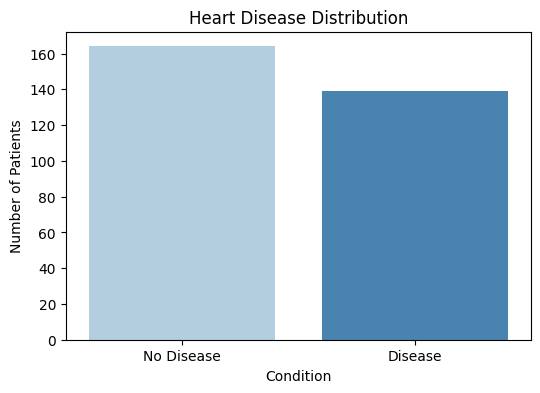

No Disease: 164
Has Disease: 139


In [79]:
# Let's see the distribution of our target
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='Blues')
plt.title('Heart Disease Distribution')
plt.xticks([0,1], ['No Disease', 'Disease'])
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
plt.show()

print("No Disease:", df['target'].value_counts()[0])
print("Has Disease:", df['target'].value_counts()[1])

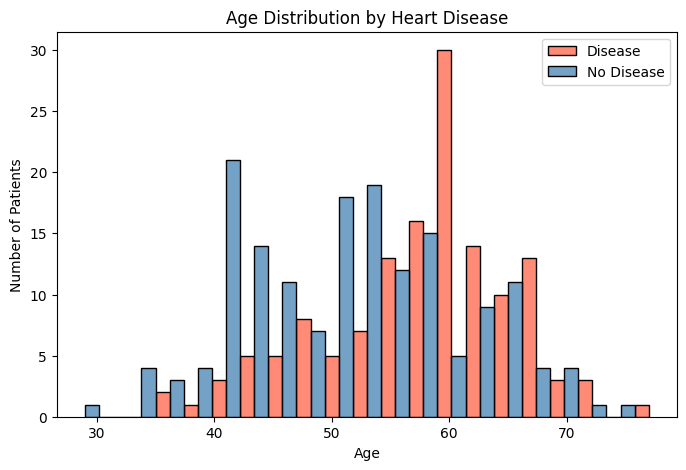

In [80]:
# Age distribution - side by side bars
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='target', bins=20,
             palette={0:'steelblue', 1:'tomato'},
             multiple='dodge')
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.legend(labels=['Disease', 'No Disease'])
plt.show()

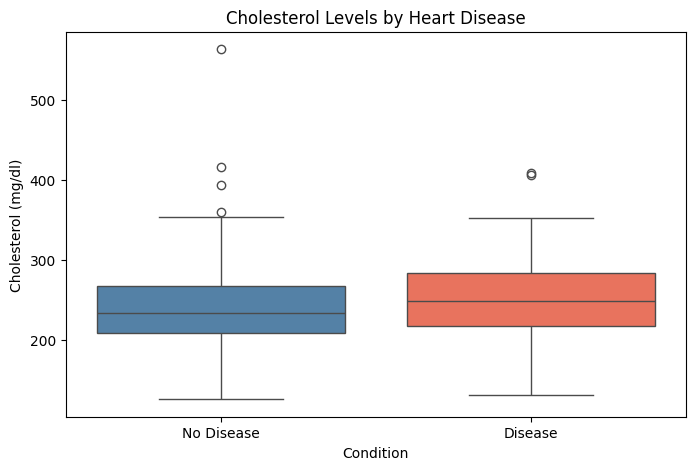

In [81]:
# Cholesterol levels by heart disease
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='chol', data=df,
            hue='target',
            palette={0:'steelblue', 1:'tomato'},
            legend=False)
plt.title('Cholesterol Levels by Heart Disease')
plt.xticks([0,1], ['No Disease', 'Disease'])
plt.xlabel('Condition')
plt.ylabel('Cholesterol (mg/dl)')
plt.show()

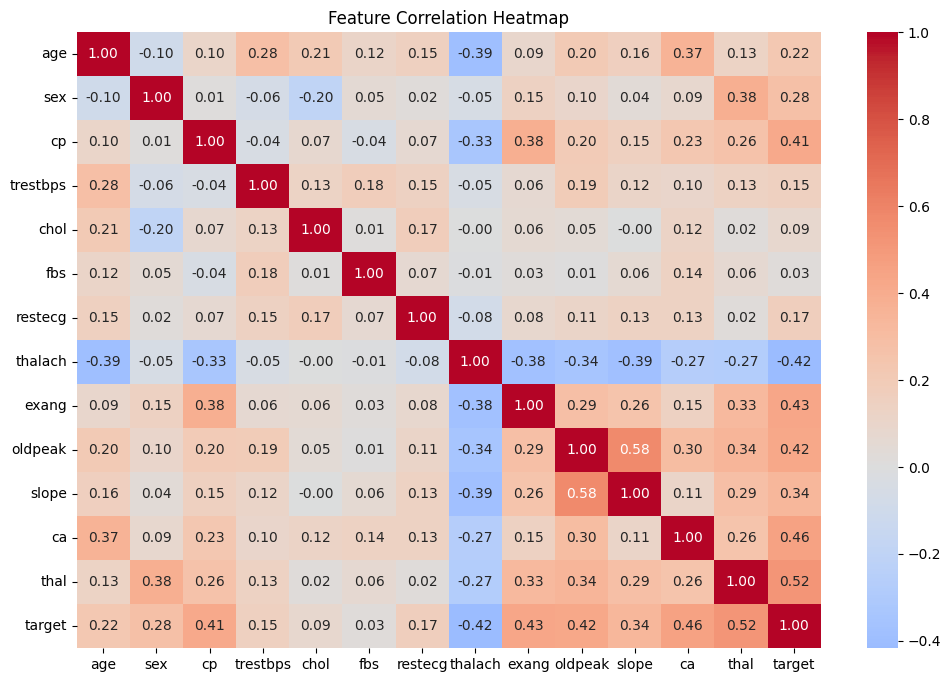

In [82]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

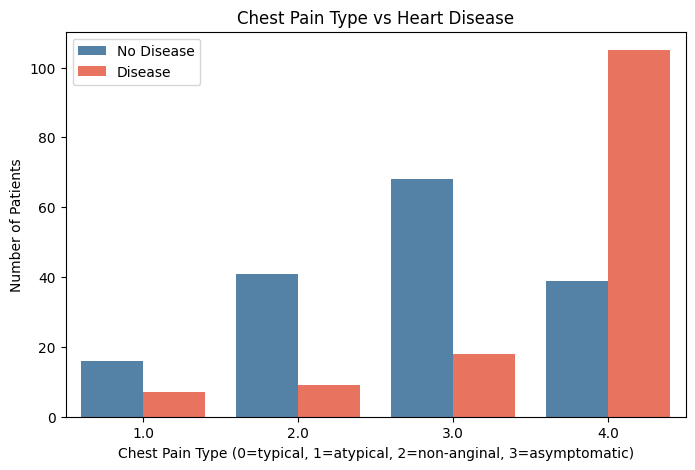

In [83]:
# Chest pain type vs heart disease
plt.figure(figsize=(8,5))
sns.countplot(x='cp', hue='target', data=df,
              palette={0:'steelblue', 1:'tomato'})
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (0=typical, 1=atypical, 2=non-anginal, 3=asymptomatic)')
plt.ylabel('Number of Patients')
plt.legend(labels=['No Disease', 'Disease'])
plt.show()

## Key EDA Findings
- Dataset nearly balanced — 164 no disease vs 139 disease
- Heart disease increases significantly after age 55
- thal and ca are strongest predictors (0.52 and 0.46 correlation)
- Cholesterol showed surprisingly weak correlation at just 0.09
- Asymptomatic patients had highest heart disease rate


## Data Preprocessing
Preparing data for ML models — scaling features to same range
using StandardScaler and splitting into 80% training, 20% testing.



In [84]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1 - Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Step 2 - Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3 - Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features:", X_train.shape[1])

Training samples: 242
Testing samples: 61
Features: 13


In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Build and train the model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Results
print("LOGISTIC REGRESSION RESULTS")
print("="*40)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8852459016393442

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



In [86]:
from sklearn.ensemble import RandomForestClassifier

# Build and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Results
print("RANDOM FOREST RESULTS")
print("="*40)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy: 0.8688524590163934

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [87]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build the neural network
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(13,)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Show model summary
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4560 - loss: 0.7749 - val_accuracy: 0.4286 - val_loss: 0.7290
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5337 - loss: 0.6913 - val_accuracy: 0.6735 - val_loss: 0.6524
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6684 - loss: 0.6189 - val_accuracy: 0.7551 - val_loss: 0.6007
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7254 - loss: 0.5843 - val_accuracy: 0.7959 - val_loss: 0.5612
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7772 - loss: 0.5527 - val_accuracy: 0.7959 - val_loss: 0.5237
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7772 - loss: 0.5195 - val_accuracy: 0.7959 - val_loss: 0.4931
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7927 - loss: 0.4561 - val_accuracy: 0.7959 - val_loss: 0.4671
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8031 - loss: 0.4641 - val_accuracy: 0.7959 - val_loss

In [89]:
# Evaluate neural network on test data
y_pred_nn = (model.predict(X_test) > 0.5).astype(int)

print("NEURAL NETWORK RESULTS")
print("="*40)
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
NEURAL NETWORK RESULTS
Accuracy: 0.8360655737704918

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



## Model Results and Comparison
Logistic Regression performed best on this small dataset.
Prioritized recall over accuracy because missing a disease
patient is clinically more dangerous than a false alarm.



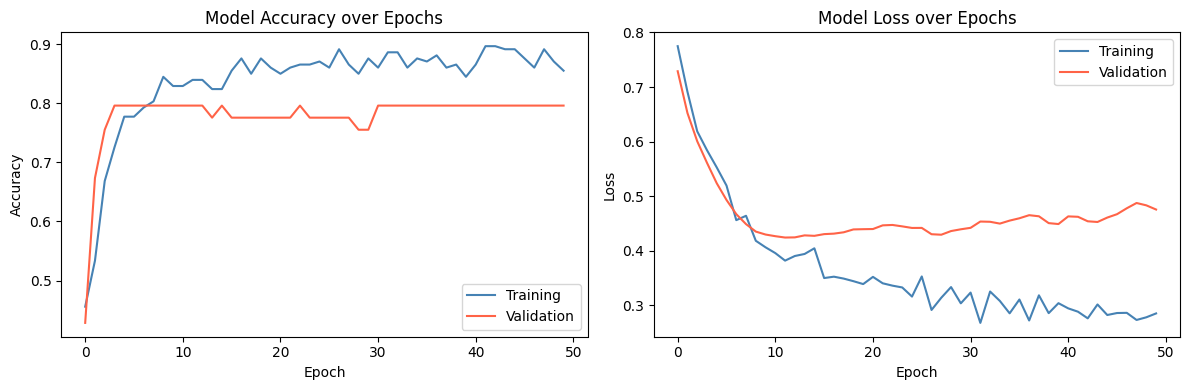

In [90]:
# Plot training history
plt.figure(figsize=(12,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],
         color='steelblue', label='Training')
plt.plot(history.history['val_accuracy'],
         color='tomato', label='Validation')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'],
         color='steelblue', label='Training')
plt.plot(history.history['val_loss'],
         color='tomato', label='Validation')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

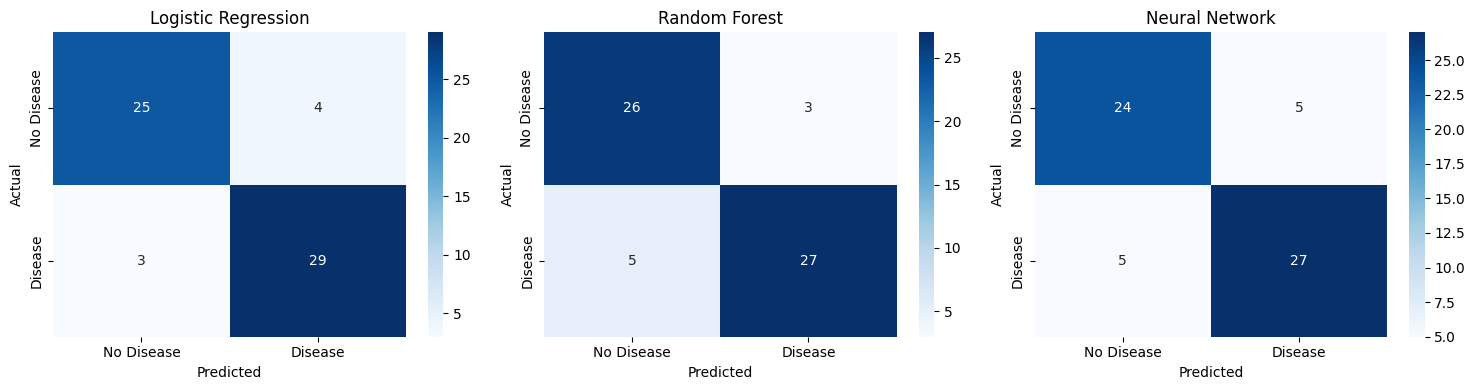

In [91]:
# Confusion Matrix for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(15,4))

models = [
    (y_pred_lr, "Logistic Regression"),
    (y_pred_rf, "Random Forest"),
    (y_pred_nn, "Neural Network")
]

for i, (pred, name) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues', ax=axes[i],
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [92]:
# Final model comparison table
results = {
    'Model': ['Logistic Regression',
               'Random Forest',
               'Neural Network'],
    'Accuracy': [0.885, 0.869, 0.820],
    'Disease Recall': [0.91, 0.84, 0.84],
    'Missed Disease Patients': [3, 5, 5]
}

results_df = pd.DataFrame(results)
print("MODEL COMPARISON")
print("="*55)
print(results_df.to_string(index=False))
print("\nBest Model: Logistic Regression")
print("Reason: Highest accuracy + lowest missed disease patients")

MODEL COMPARISON
              Model  Accuracy  Disease Recall  Missed Disease Patients
Logistic Regression     0.885            0.91                        3
      Random Forest     0.869            0.84                        5
     Neural Network     0.820            0.84                        5

Best Model: Logistic Regression
Reason: Highest accuracy + lowest missed disease patients


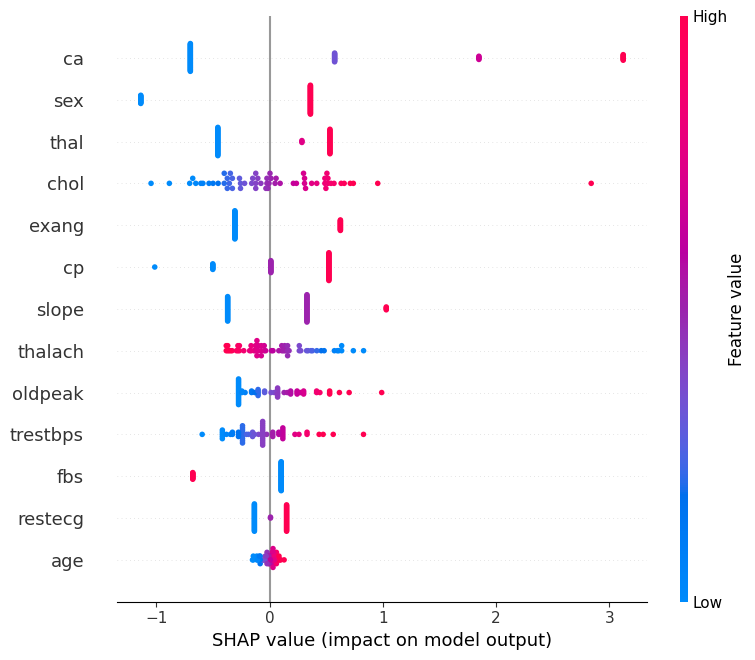

In [93]:
import shap

# SHAP for Logistic Regression
explainer = shap.LinearExplainer(lr_model, X_train)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=['age','sex','cp','trestbps','chol',
                                'fbs','restecg','thalach','exang',
                                'oldpeak','slope','ca','thal'],
                  show=True)

In [94]:
# Model comparison table
results = {
    'Model': ['Logistic Regression',
               'Random Forest',
               'Neural Network'],
    'Accuracy': ['88.5%', '86.8%', '82.0%'],
    'Disease Recall': ['91%', '84%', '84%'],
    'Missed Disease Patients': [3, 5, 5],
    'Winner': ['✅ Best', '', '']
}

results_df = pd.DataFrame(results)
print("FINAL MODEL COMPARISON")
print("="*60)
print(results_df.to_string(index=False))
print("\n✅ Best Model: Logistic Regression")
print("Reason: Highest accuracy + lowest missed disease patients")

# Save best model
import pickle
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("\n✅ Model saved as heart_disease_model.pkl")

# Export predictions to CSV for Power BI
import numpy as np
predictions_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_lr,
    'probability': lr_model.predict_proba(X_test)[:,1].round(3)
})
predictions_df.to_csv('predictions.csv', index=False)
print("✅ Predictions exported to predictions.csv")

FINAL MODEL COMPARISON
              Model Accuracy Disease Recall  Missed Disease Patients Winner
Logistic Regression    88.5%            91%                        3 ✅ Best
      Random Forest    86.8%            84%                        5       
     Neural Network    82.0%            84%                        5       

✅ Best Model: Logistic Regression
Reason: Highest accuracy + lowest missed disease patients

✅ Model saved as heart_disease_model.pkl
✅ Predictions exported to predictions.csv


## Conclusion
Best model: Logistic Regression — 88.5% accuracy, 91% disease recall.
SHAP confirmed thal and ca as strongest predictors.
Key finding: Asymptomatic patients had highest disease rate.
Future work: Deploy model as web app using Flask.





---

